In [21]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def bilinear(image, row, col):
    """
    Return the interpolated value for row, col in image.
    Assume rol, col are non-negative and less than the width and height of image -1

    Input- image: H x W
    row, col: floating point scalar
    Output - value: scalar
    """
    H, W = image.shape
    row_int = int(row)
    col_int = int(col)
    row_frac = row - row_int
    col_frac = col - col_int

    if ((0<= row_int and row_int< H-1) and (0 <= col_int and col_int< W-1)) != True:
        return np.uint8(0)

    else:
      temp00= float(image[row_int, col_int])
      temp10= float(image[row_int, col_int + 1])
      temp01= float(image[row_int + 1, col_int])
      temp11= float(image[row_int + 1, col_int + 1])

      w00= (1.0- row_frac)*(1.0- col_frac)
      w10= (1.0- row_frac)*col_frac
      w01= row_frac*(1.0- col_frac)
      w11= row_frac*col_frac

      value= np.uint8(np.clip(w00 * temp00 + w10 * temp10 + w01 * temp01 + w11 * temp11+0.5, 0, 255))
      return value


In [23]:
def imshow(image, *args, **kwargs):
    if len(image.shape) == 3:
      # Height, width, channels
      # Assume BGR, do a conversion since
      image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    else:
      # Height, width - must be grayscale
      # convert to RGB, since matplotlib will plot in a weird colormap (instead of black = 0, white = 1)
      image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    # Draw the image
    plt.imshow(image, *args, **kwargs)
    # We'll also disable drawing the axes and tick marks in the plot, since it's actually an image
    plt.axis('off')
    # Make sure it outputs
    plt.show()

Mounted at /content/gdrive


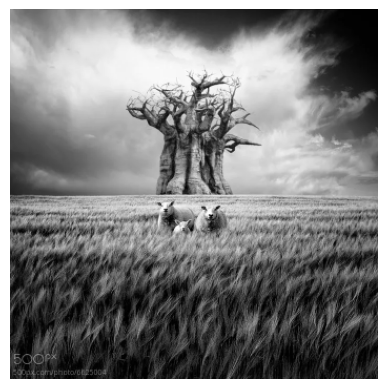

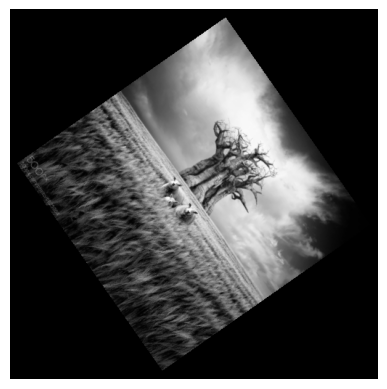

In [24]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
rootpath = '/content/gdrive/MyDrive/cs558_resources/imrot'
input = cv2.imread(os.path.join(rootpath, "bnw_small.png"))
input = cv2.cvtColor(input, cv2.COLOR_BGR2GRAY)
imshow(input)

output = np.zeros((int(1.45*input.shape[0]), int(1.45*input.shape[1])),dtype='uint8')

# consider both nearest-neighbor and bilinear interpolation
# change theta for whatever angle
theta = 55
# change 'bilinear' to 'nearest' and vice versa
interpolation = "bilinear"

tempHin, tempWin = input.shape
tempHout, tempWout = output.shape

tempXin= (tempWin-1)/2
tempXout= (tempWout-1)/2
tempYin= (tempHin-1)/2
tempYout= (tempHout-1)/2

rads= np.deg2rad(theta)
c, s= np.cos(rads), np.sin(rads)

output[:]= 0

for yOut in (range(tempHout)):
    dy= yOut-tempYout
    for xOut in (range(tempWout)):
        dx= xOut-tempXout
        xInC= c*dx+ s*dy
        yInC= -1*s*dx+ c*dy
        xIn= xInC+tempXin
        yIn= yInC+tempYin

        if (interpolation == "nearest"):
            xi= int(round(xIn))
            yi = int(round(yIn))
            if (0<=xi and xi<tempWin) and (0 <= yi and yi < tempHout):
                output[yOut, xOut] = input[yi, xi]
        else:
            if (0 <= yIn and yIn < tempHout-1) and (0 <= xIn and xIn < tempWin-1):
                output[yOut, xOut]= bilinear(input, yIn, xIn)
imshow(output)
